# Water Quality Prediction — Best Model Notebook

## Challenge Overview

Welcome to the EY AI & Data Challenge 2026!  
The objective of this challenge is to build a robust **machine learning model** capable of predicting water quality across various river locations in South Africa. In addition to accurate predictions, the model should also identify and emphasize the key factors that significantly influence water quality.

Participants will be provided with a dataset containing three water quality parameters — **Total Alkalinity**, **Electrical Conductance**, and **Dissolved Reactive Phosphorus** — collected between 2011 and 2015 from approximately 200 river locations across South Africa. Each data point includes the geographic coordinates (latitude and longitude) of the sampling site, the date of collection, and the corresponding water quality measurements.

Using this dataset, participants are expected to build a machine learning model to predict water quality parameters for a separate validation dataset, which includes locations from different regions not present in the training data. The challenge also encourages participants to explore feature importance and provide insights into the factors most strongly associated with variations in water quality.

This challenge is designed for participants with varying levels of experience in data science, remote sensing, and environmental analytics. It offers a valuable opportunity to apply machine learning techniques to real-world environmental data and contribute to advancing water quality monitoring using artificial intelligence.

This notebook predicts **Total Alkalinity (TA)**, **Electrical Conductance (EC)**, and **Dissolved Reactive Phosphorus (DRP)** for South African river locations using **15 features** from Landsat and TerraClimate.

**Key improvements over the benchmark:**

- **Landsat calibration** — DN values converted to surface reflectance via C2L2 (`DN × 0.0000275 − 0.2`)
- **Cloud filter** — reflectance clamped to `[0.0, 1.2]`, preventing inverted denominators in ratio indices
- **Cluster-based spatial imputation** — KMeans (8 clusters on lat/lon), with pre-filter band medians as fallback
- **DRP censoring** — detection limit value `10.0` replaced with `DL/2 = 5.0`
- **Winsorization** — 1% on both tails of targets before `log1p` transform
- **Expanded features** — 6 TerraClimate (ppt, def, soil, pet, aet, q) + 4 calibrated Landsat bands (nir, green, swir16, swir22) + 3 spectral indices (NDMI, MNDWI, NDVI) + 2 cyclic seasonality (month_sin, month_cos)
- **RandomizedSearchCV** with **GroupKFold** (5 folds by station) — spatial CV with 50 random XGBoost hyperparameter combinations
- **log1p / expm1 target transform** — stabilizes training on right-skewed distributions

## Load In Dependencies
The following code installs the required Python libraries (found in the requirements.txt file) in the Snowflake environment to allow successful execution of the remaining notebook code. After running this code for the first time, it is required to “restart” the kernal so the Python libraries are available in the environment. This is done by selecting the “Connected” menu above the notebook (next to “Run all”) and selecting the “restart kernal” link. Subsequent runs of the notebook do not require this “restart” process.

In [1]:
!pip install uv
!uv pip install -r requirements.txt xgboost

Using Python 3.12.3 environment at: /home/isaac/Documents/ey-hackathon/.venv
Audited 21 packages in 14ms


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import mstats, uniform, randint

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, make_scorer

from xgboost import XGBRegressor

## 1. Load & Merge Data

> **Note:** After the merge, see **Section 2 (EDA)** for exploratory analysis before preprocessing begins in Section 3.

We load the **water quality training dataset** and merge it with all available **Landsat** and **TerraClimate** CSV files using `(Latitude, Longitude, Sample Date)` as join keys — never by index.

In [27]:
JOIN_KEYS = ['Latitude', 'Longitude', 'Sample Date']
BANDS = ['nir', 'green', 'swir16', 'swir22', 'red']

wq_orig     = pd.read_csv('water_quality_training_dataset.csv')
wq_new      = pd.read_csv('water_quality_new_training_dataset.csv')

wq = pd.concat([wq_orig, wq_new], ignore_index=True) \
       .drop_duplicates(subset=JOIN_KEYS, keep='first') \
       .reset_index(drop=True)

landsat     = pd.read_csv('landsat_features_training.csv')
landsat_new = pd.read_csv('landsat_new_features_training.csv')   # adds: red
terra       = pd.read_csv('terraclimate_features_training.csv')
terra_new   = pd.read_csv('terraclimate_new_features_training.csv')  # adds: ppt, def, soil, q, aet

df = wq.merge(landsat,     on=JOIN_KEYS, how='left') \
        .merge(landsat_new, on=JOIN_KEYS, how='left') \
        .merge(terra,       on=JOIN_KEYS, how='left') \
        .merge(terra_new,   on=JOIN_KEYS, how='left')

print(f'Shape after merge: {df.shape}')
print(f'Unique stations: {df[["Latitude","Longitude"]].drop_duplicates().shape[0]}')
display(df.head(5))

Shape after merge: (12690, 20)
Unique stations: 171


,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus,nir,green,swir16,swir22,NDMI,MNDWI,blue,red,pet,ppt,soil,def,q,aet
0,-28.760833,17.730278,02-01-2011,128.912,555.0,10.0,11190.0,11426.0,7687.5,7645.0,0.185538,0.195595,9557.0,12802.0,174.2,32.7,0.0,143.100000,1.6,31.100000
1,-26.861111,28.884722,03-01-2011,74.720,162.9,163.0,17658.5,9550.0,13746.5,10574.0,0.124566,-0.180134,8691.0,9241.5,124.1,51.1,12.8,70.300000,2.6,53.800000
2,-26.450000,28.085833,03-01-2011,89.254,573.0,80.0,15210.0,10720.0,17974.0,14201.0,-0.083293,-0.252805,9502.5,12540.0,127.5,62.7,6.8,66.700005,3.1,60.800000
3,-27.671111,27.236944,03-01-2011,82.000,203.6,101.0,14887.0,10943.0,13522.0,11403.0,0.048048,-0.105416,9693.5,11237.5,129.7,84.2,7.2,46.500000,4.2,83.200005
4,-27.356667,27.286389,03-01-2011,56.100,145.1,151.0,16828.5,9502.5,12665.5,9643.0,0.141147,-0.142683,8718.0,9290.0,129.2,78.0,7.8,51.900000,3.9,77.300000


## 2. Exploratory Data Analysis

Before any preprocessing, we explore the raw data to understand:
- **Dataset sizes** and missing value patterns across all sources
- **Geographic distribution** — where are train vs test stations?
- **Target distributions** — skewness, outliers, detection-limit censoring in DRP
- **Temporal patterns** — seasonal trends in water quality (2011–2015)
- **Feature correlations** — which satellite/climate variables relate most to the targets?
- **Spatial patterns** — do water quality values vary geographically?

### 2.1 Dataset Overview — Shapes & Missing Values

In [28]:
# ── 2.1 Dataset overview ──────────────────────────────────────────────────────
_datasets = {
    'water_quality_training':      wq,
    'landsat_training':            landsat,
    'landsat_new_training':        landsat_new,
    'terraclimate_training':       terra,
    'terraclimate_new_training':   terra_new,
    'merged_train (df)':           df,
}

# Load raw test files just for EDA (not yet processed)
_landsat_test     = pd.read_csv('landsat_features_validation.csv')
_landsat_new_test = pd.read_csv('landsat_new_features_validation.csv')
_terra_test       = pd.read_csv('terraclimate_features_validation.csv')
_terra_new_test   = pd.read_csv('terraclimate_new_features_validation.csv')
_test_raw = _landsat_test.merge(_landsat_new_test, on=JOIN_KEYS, how='left') \
                         .merge(_terra_test,        on=JOIN_KEYS, how='left') \
                         .merge(_terra_new_test,    on=JOIN_KEYS, how='left')

_datasets['merged_test (raw)'] = _test_raw

print(f"{'Dataset':<35} {'Rows':>6}  {'Cols':>4}  {'Missing cells':>14}  {'% missing':>10}")
print('─' * 75)
for name, d in _datasets.items():
    miss = d.isna().sum().sum()
    pct  = 100 * miss / d.size
    print(f"{name:<35} {len(d):>6}  {d.shape[1]:>4}  {miss:>14,}  {pct:>9.1f}%")

print(f"\nTraining unique stations: {wq[['Latitude','Longitude']].drop_duplicates().shape[0]}")
print(f"Test unique stations:     {_test_raw[['Latitude','Longitude']].drop_duplicates().shape[0]}")
dates_wq = pd.to_datetime(wq['Sample Date'], dayfirst=True)
print(f"Training date range:      {dates_wq.min().date()} → {dates_wq.max().date()}")


Dataset                               Rows  Cols   Missing cells   % missing
───────────────────────────────────────────────────────────────────────────
water_quality_training               12690     6             399        0.5%
landsat_training                      9319     9           6,510        7.8%
landsat_new_training                  9319     5           2,170        4.7%
terraclimate_training                 9319     4               0        0.0%
terraclimate_new_training             9319     8               0        0.0%
merged_train (df)                    12690    20          56,273       22.2%
merged_test (raw)                      200    17             152        4.5%

Training unique stations: 171
Test unique stations:     24
Training date range:      1971-09-20 → 2022-05-25


### 2.2 Geographic Distribution — Train vs Test Stations

The validation (test) stations are in **different geographic regions** from the training stations — this is a **spatial generalisation** challenge. The map below highlights where training and test points are located across South Africa.

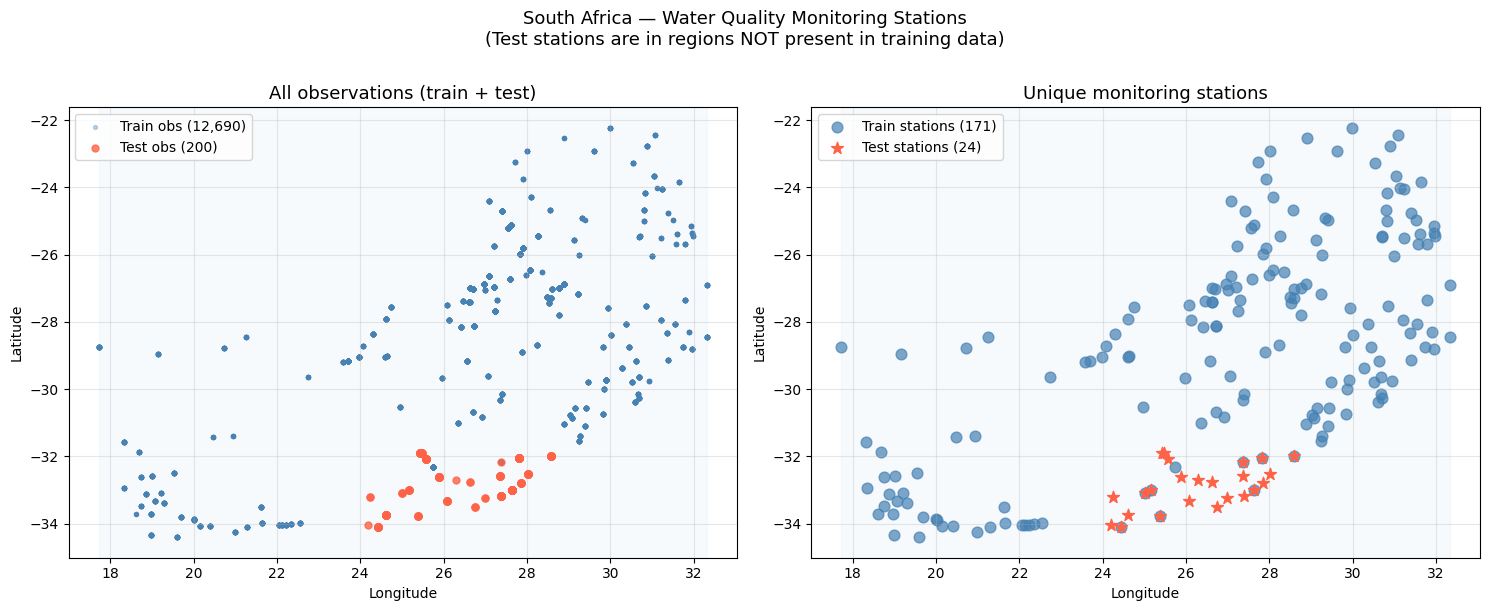


Train bbox: lat [-34.41, -22.23]  lon [17.73, 32.33]
Test  bbox: lat [-34.10,  -31.90]  lon [24.20, 28.58]

Geographic overlap — Latitude: True | Longitude: True


In [29]:
# ── 2.2 Geographic distribution ──────────────────────────────────────────────
train_stations = wq[['Latitude', 'Longitude']].drop_duplicates()
test_stations  = _test_raw[['Latitude', 'Longitude']].drop_duplicates()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: all individual observations
ax = axes[0]
ax.scatter(df['Longitude'], df['Latitude'],
           s=8, alpha=0.35, color='steelblue', label=f'Train obs ({len(df):,})')
ax.scatter(_test_raw['Longitude'], _test_raw['Latitude'],
           s=25, alpha=0.8, color='tomato', label=f'Test obs ({len(_test_raw):,})', zorder=3)
ax.set_title('All observations (train + test)', fontsize=13)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

# Right: unique stations only
ax = axes[1]
ax.scatter(train_stations['Longitude'], train_stations['Latitude'],
           s=60, alpha=0.7, color='steelblue', label=f'Train stations ({len(train_stations)})')
ax.scatter(test_stations['Longitude'], test_stations['Latitude'],
           s=80, marker='*', color='tomato', label=f'Test stations ({len(test_stations)})', zorder=3)
ax.set_title('Unique monitoring stations', fontsize=13)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

# Annotate geographic bounding boxes
for ax in axes:
    ax.axvspan(train_stations['Longitude'].min(), train_stations['Longitude'].max(),
               alpha=0.04, color='steelblue')

plt.suptitle('South Africa — Water Quality Monitoring Stations\n'
             '(Test stations are in regions NOT present in training data)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"\nTrain bbox: lat [{train_stations['Latitude'].min():.2f}, {train_stations['Latitude'].max():.2f}]  "
      f"lon [{train_stations['Longitude'].min():.2f}, {train_stations['Longitude'].max():.2f}]")
print(f"Test  bbox: lat [{test_stations['Latitude'].min():.2f},  {test_stations['Latitude'].max():.2f}]  "
      f"lon [{test_stations['Longitude'].min():.2f}, {test_stations['Longitude'].max():.2f}]")

# Overlap check
lat_overlap = (test_stations['Latitude'].min() <= train_stations['Latitude'].max()) and \
              (test_stations['Latitude'].max() >= train_stations['Latitude'].min())
lon_overlap = (test_stations['Longitude'].min() <= train_stations['Longitude'].max()) and \
              (test_stations['Longitude'].max() >= train_stations['Longitude'].min())
print(f"\nGeographic overlap — Latitude: {lat_overlap} | Longitude: {lon_overlap}")


### 2.3 Target Distributions — Skewness & Detection Limit

Water quality parameters are **right-skewed** (long positive tails). DRP has a notable spike at `10.0` — the analytical **detection limit** (values below this threshold are reported as 10). This motivates the `log1p` transform and DRP censoring (`10 → 5`).

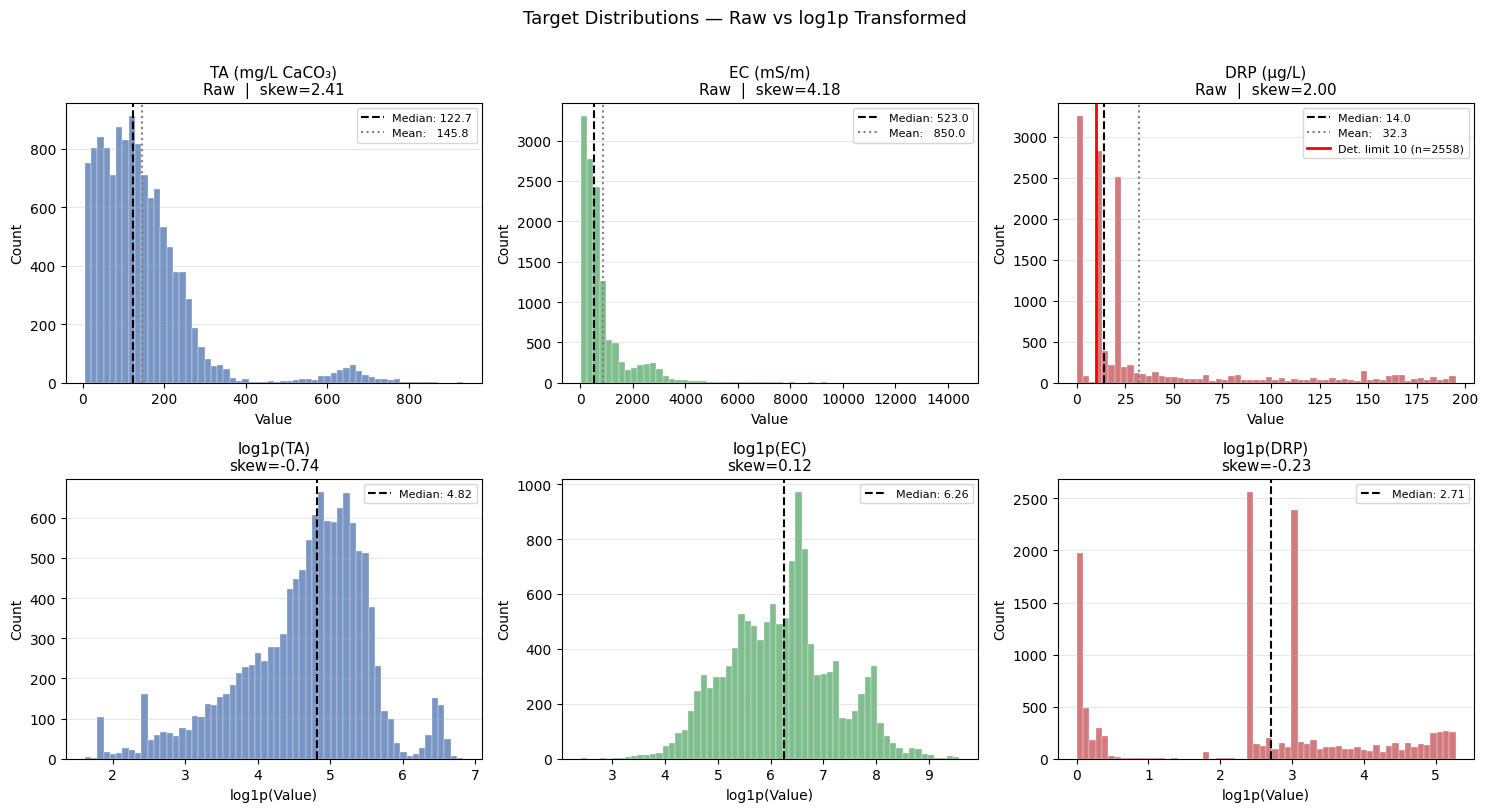


Descriptive statistics (raw targets):


,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
count,12412.00,12678.00,12581.00
mean,145.82,849.99,32.28
std,124.72,1108.16,47.81
min,4.00,10.00,0.00
25%,64.12,243.00,0.52
50%,122.74,523.00,14.00
75%,189.50,896.88,25.00
max,934.00,14436.00,195.00


In [30]:
# ── 2.3 Target distributions ─────────────────────────────────────────────────
TARGETS = ['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']
TARGET_LABELS = ['TA (mg/L CaCO₃)', 'EC (mS/m)', 'DRP (µg/L)']
COLORS = ['#4C72B0', '#55A868', '#C44E52']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, (col, label, color) in enumerate(zip(TARGETS, TARGET_LABELS, COLORS)):
    vals = wq[col].dropna()

    # Raw distribution
    ax = axes[0, i]
    ax.hist(vals, bins=60, color=color, alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(vals.median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {vals.median():.1f}')
    ax.axvline(vals.mean(),   color='grey',  linestyle=':',  linewidth=1.5,
               label=f'Mean:   {vals.mean():.1f}')
    if col == 'Dissolved Reactive Phosphorus':
        dl_count = (vals == 10.0).sum()
        ax.axvline(10.0, color='red', linestyle='-', linewidth=2,
                   label=f'Det. limit 10 (n={dl_count})')
    ax.set_title(f'{label}\nRaw  |  skew={vals.skew():.2f}', fontsize=11)
    ax.set_xlabel('Value'); ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    # log1p distribution
    ax = axes[1, i]
    log_vals = np.log1p(vals)
    ax.hist(log_vals, bins=60, color=color, alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(log_vals.median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {log_vals.median():.2f}')
    ax.set_title(f'log1p({label.split(" ")[0]})\nskew={log_vals.skew():.2f}', fontsize=11)
    ax.set_xlabel('log1p(Value)'); ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Target Distributions — Raw vs log1p Transformed', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\nDescriptive statistics (raw targets):")
display(wq[TARGETS].describe().round(2))


### 2.4 Temporal Analysis — Seasonal & Annual Patterns

Monthly medians per year reveal clear **seasonal cycles** in water quality, driven by the South African wet season (October–April). The number of samples per month shows the sampling effort over time.

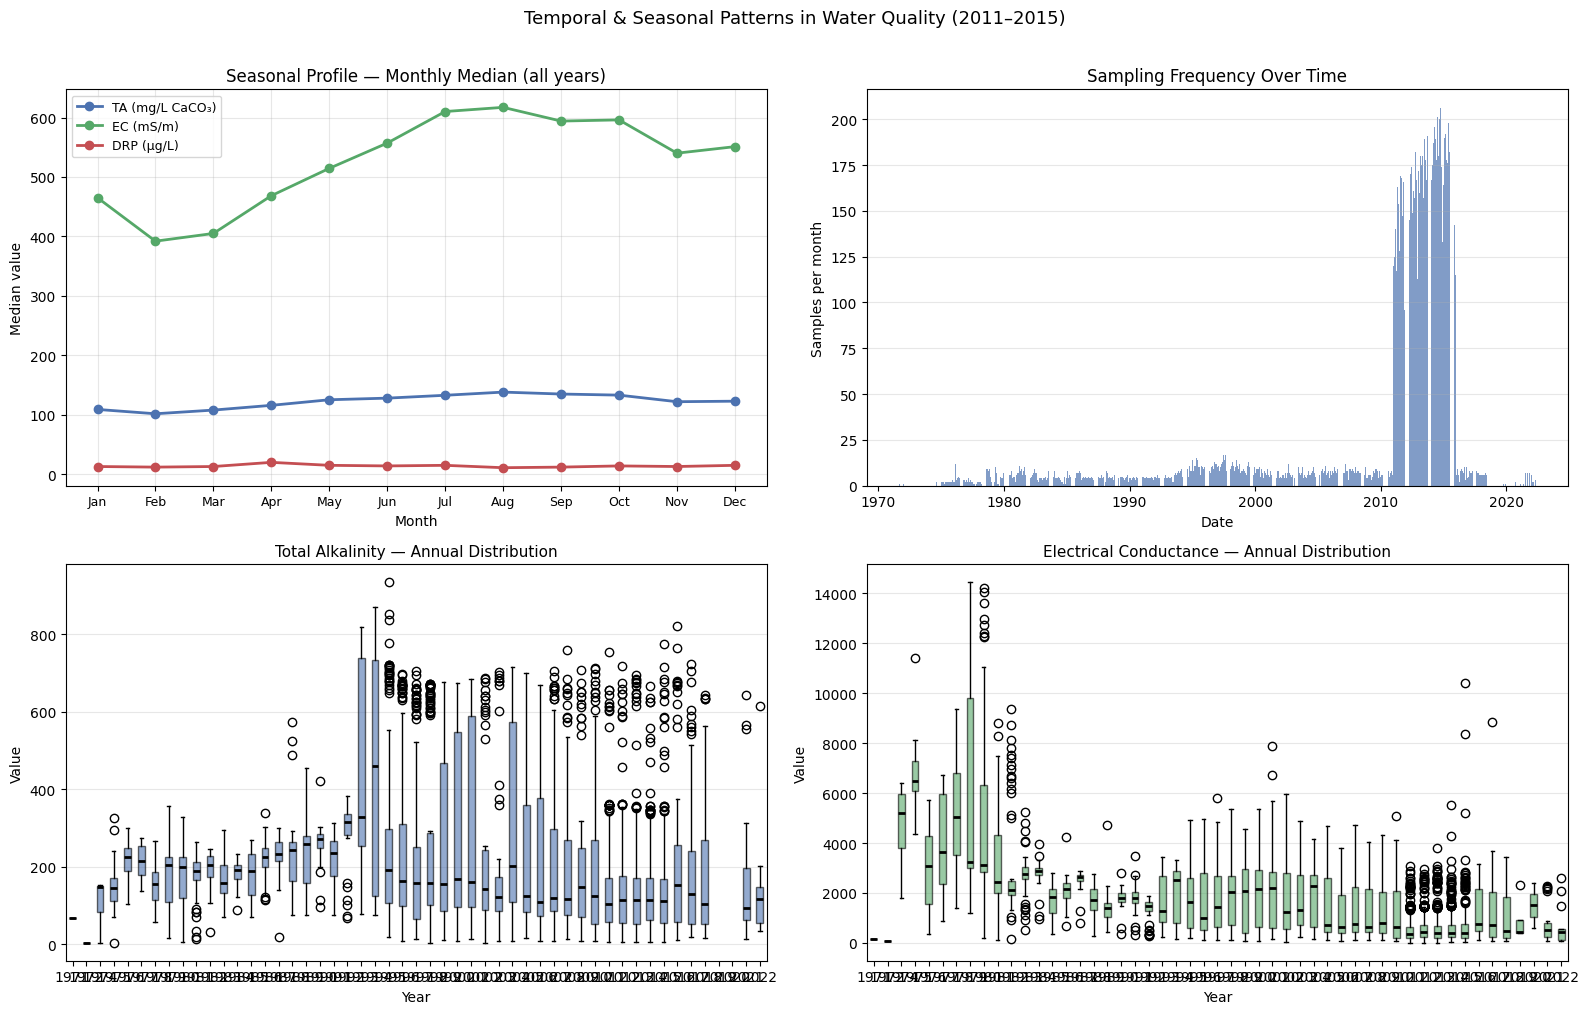

DRP at detection limit (value = 10.0) per year:


,total,at_DL,% at DL
year,,,
1971,1,0,0.0%
1972,1,0,0.0%
1974,7,0,0.0%
1975,24,0,0.0%
1976,49,0,0.0%
1977,23,0,0.0%
1978,64,0,0.0%
1979,36,0,0.0%
1980,68,0,0.0%


In [31]:
# ── 2.4 Temporal analysis ─────────────────────────────────────────────────────
_wq_time = wq.copy()
_wq_time['date']  = pd.to_datetime(_wq_time['Sample Date'], dayfirst=True)
_wq_time['year']  = _wq_time['date'].dt.year
_wq_time['month'] = _wq_time['date'].dt.month
_wq_time['ym']    = _wq_time['date'].dt.to_period('M').dt.to_timestamp()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Monthly median per target (seasonal profile across all years)
ax = axes[0, 0]
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for col, label, color in zip(TARGETS, TARGET_LABELS, COLORS):
    monthly = _wq_time.groupby('month')[col].median()
    ax.plot(monthly.index, monthly.values, marker='o', label=label, color=color, linewidth=2)
ax.set_xticks(range(1, 13)); ax.set_xticklabels(month_names, fontsize=9)
ax.set_title('Seasonal Profile — Monthly Median (all years)', fontsize=12)
ax.set_xlabel('Month'); ax.set_ylabel('Median value')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Sample count per year-month
ax = axes[0, 1]
counts = _wq_time.groupby('ym').size()
ax.bar(counts.index, counts.values, width=25, color='#4C72B0', alpha=0.7)
ax.set_title('Sampling Frequency Over Time', fontsize=12)
ax.set_xlabel('Date'); ax.set_ylabel('Samples per month')
ax.grid(axis='y', alpha=0.3)

# Annual boxplots per target (TA + EC stacked, DRP separate)
for col, ax, color in zip(TARGETS[:2], [axes[1, 0], axes[1, 1]], COLORS[:2]):
    data_by_year = [_wq_time[_wq_time['year'] == y][col].dropna().values
                    for y in sorted(_wq_time['year'].unique())]
    bp = ax.boxplot(data_by_year, patch_artist=True, medianprops=dict(color='black', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor(color); patch.set_alpha(0.6)
    ax.set_xticklabels(sorted(_wq_time['year'].unique()))
    ax.set_title(f'{col} — Annual Distribution', fontsize=11)
    ax.set_xlabel('Year'); ax.set_ylabel('Value')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Temporal & Seasonal Patterns in Water Quality (2011–2015)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# DRP detection limit proportion per year
print("DRP at detection limit (value = 10.0) per year:")
drp_dl = _wq_time.groupby('year').apply(
    lambda g: pd.Series({
        'total': len(g),
        'at_DL': (g['Dissolved Reactive Phosphorus'] == 10.0).sum(),
        '% at DL': f"{100*(g['Dissolved Reactive Phosphorus']==10.0).mean():.1f}%"
    })
)
display(drp_dl)


### 2.5 Feature Correlations with Targets

Pearson correlations between all raw satellite/climate features and the three water quality targets. Darker cells indicate stronger linear relationships — though XGBoost can capture non-linear associations too.

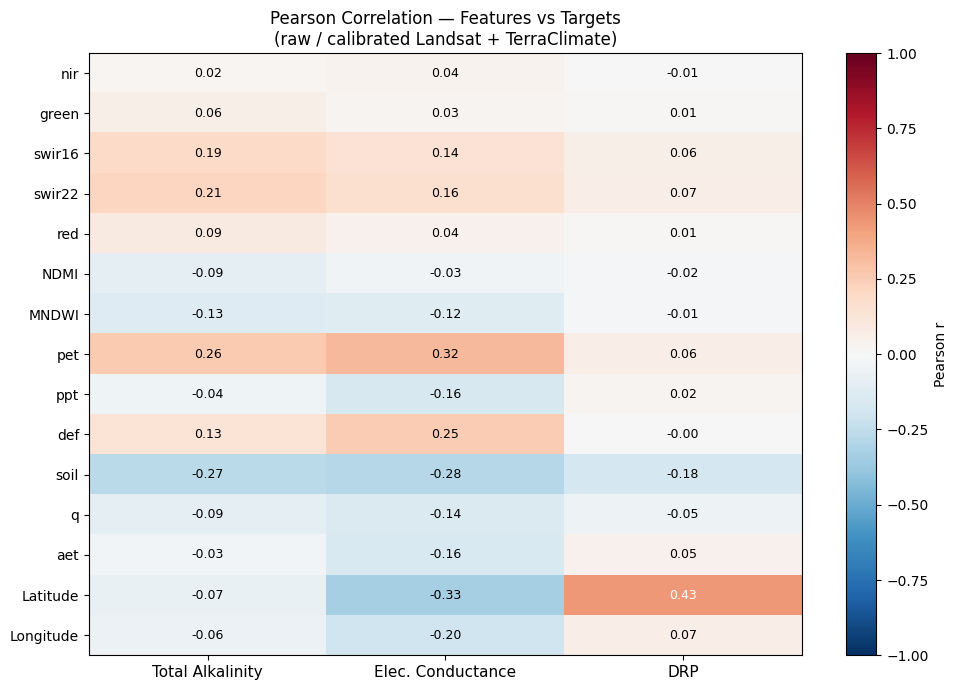


Top 5 features by absolute correlation with each target:

  Total Alkalinity:
    soil                 r = -0.271
    pet                  r = +0.264
    swir22               r = +0.211
    swir16               r = +0.192
    def                  r = +0.134

  Electrical Conductance:
    Latitude             r = -0.334
    pet                  r = +0.323
    soil                 r = -0.282
    def                  r = +0.250
    Longitude            r = -0.200

  Dissolved Reactive Phosphorus:
    Latitude             r = +0.432
    soil                 r = -0.177
    Longitude            r = +0.070
    swir22               r = +0.066
    pet                  r = +0.063


In [32]:
# ── 2.5 Feature correlations ─────────────────────────────────────────────────
# Build a single dataframe with all raw features + targets (before calibration)
_eda = wq.merge(landsat,     on=JOIN_KEYS, how='left') \
         .merge(landsat_new, on=JOIN_KEYS, how='left') \
         .merge(terra,       on=JOIN_KEYS, how='left') \
         .merge(terra_new,   on=JOIN_KEYS, how='left')

_feat_cols = ['nir', 'green', 'swir16', 'swir22', 'red',
              'NDMI', 'MNDWI',
              'pet', 'ppt', 'def', 'soil', 'q', 'aet',
              'Latitude', 'Longitude']

# Compute NDMI / MNDWI from raw DN for correlation (approximate, un-calibrated)
_scale, _offset = 0.0000275, -0.2
for _b in ['nir', 'green', 'swir16', 'swir22', 'red']:
    if _b in _eda.columns:
        _eda[_b] = _eda[_b] * _scale + _offset
_eda['NDMI']  = (_eda['nir'] - _eda['swir16']) / (_eda['nir'] + _eda['swir16']).replace(0, np.nan)
_eda['MNDWI'] = (_eda['green'] - _eda['swir22']) / (_eda['green'] + _eda['swir22']).replace(0, np.nan)

_available = [c for c in _feat_cols if c in _eda.columns]
_corr_data  = _eda[_available + TARGETS].copy()
_corr_matrix = _corr_data[_available].corrwith(_corr_data[TARGETS[0]]).to_frame(TARGETS[0])
for t in TARGETS[1:]:
    _corr_matrix[t] = _corr_data[_available].corrwith(_corr_data[t])
_corr_matrix = _corr_matrix.round(3)

# Plot heatmap using matplotlib (no seaborn dependency)
fig, ax = plt.subplots(figsize=(10, 7))
_vals = _corr_matrix.values
im = ax.imshow(_vals, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_xticks(range(len(TARGETS)))
ax.set_xticklabels(['Total Alkalinity', 'Elec. Conductance', 'DRP'], fontsize=11)
ax.set_yticks(range(len(_available)))
ax.set_yticklabels(_available, fontsize=10)
for i in range(len(_available)):
    for j in range(len(TARGETS)):
        v = _vals[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=9, color='white' if abs(v) > 0.4 else 'black')
ax.set_title('Pearson Correlation — Features vs Targets\n(raw / calibrated Landsat + TerraClimate)', fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 5 features by absolute correlation with each target:")
for t in TARGETS:
    top5 = _corr_matrix[t].abs().sort_values(ascending=False).head(5)
    print(f"\n  {t}:")
    for feat, r in top5.items():
        print(f"    {feat:<20} r = {_corr_matrix.loc[feat, t]:+.3f}")


### 2.6 Spatial Patterns of Water Quality Targets

Each observation is plotted on the geographic map of South Africa, coloured by the target value. This reveals **spatial gradients** — e.g., high EC/TA in arid western regions (lower rainfall, more mineral dissolution) versus lower values in wetter eastern areas.

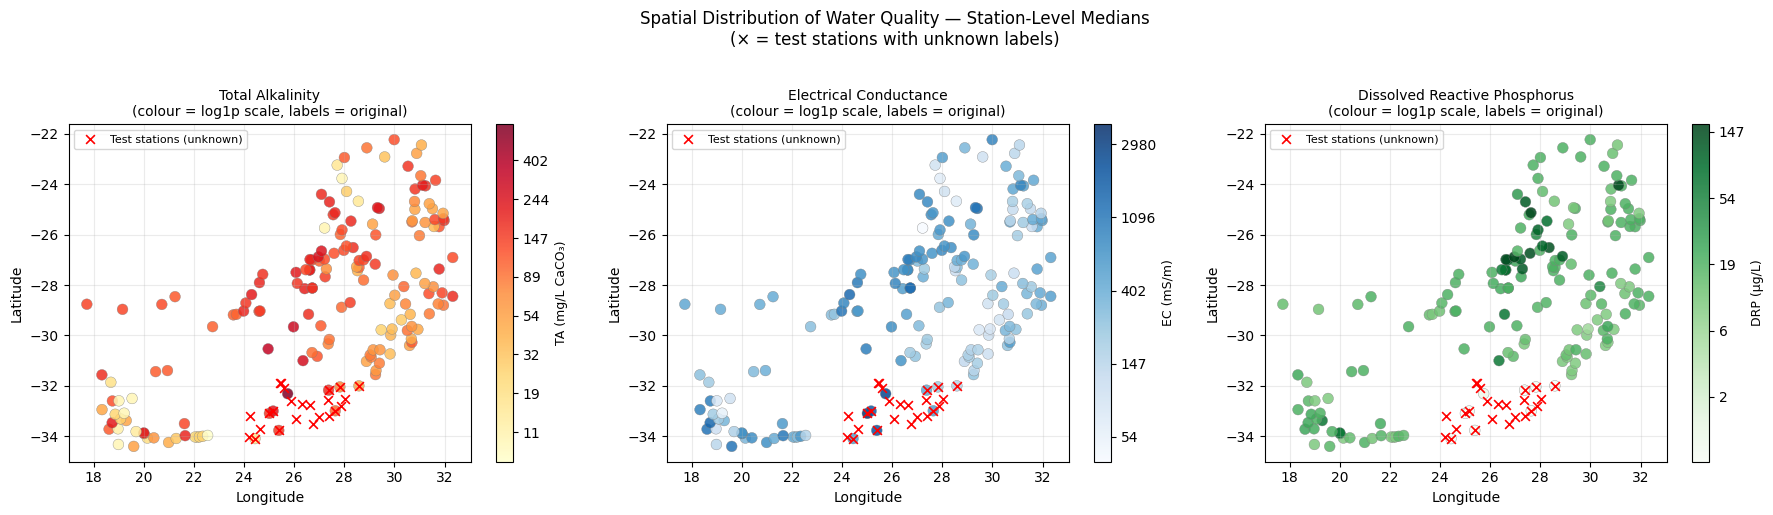

In [33]:
# ── 2.6 Spatial patterns ─────────────────────────────────────────────────────
# Use station-level median to reduce noise
_station_med = wq.groupby(['Latitude', 'Longitude'])[TARGETS].median().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmaps = ['YlOrRd', 'Blues', 'Greens']

for ax, col, label, cmap in zip(axes, TARGETS, TARGET_LABELS, cmaps):
    sc = ax.scatter(
        _station_med['Longitude'], _station_med['Latitude'],
        c=np.log1p(_station_med[col]),
        cmap=cmap, s=60, alpha=0.85, edgecolors='grey', linewidth=0.3
    )
    cbar = plt.colorbar(sc, ax=ax)
    # Rebuild tick labels in original scale
    log_ticks = cbar.get_ticks()
    cbar.set_ticklabels([f'{np.expm1(t):.0f}' for t in log_ticks])
    cbar.set_label(label, fontsize=9)
    ax.set_title(f'{col}\n(colour = log1p scale, labels = original)', fontsize=10)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.grid(alpha=0.25)
    # Mark test region
    ax.scatter(test_stations['Longitude'], test_stations['Latitude'],
               marker='x', color='red', s=40, linewidths=1.2,
               label='Test stations (unknown)', zorder=5)
    ax.legend(fontsize=8)

plt.suptitle('Spatial Distribution of Water Quality — Station-Level Medians\n'
             '(× = test stations with unknown labels)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 3. Landsat Calibration (DN → Reflectance)

Apply Landsat Collection 2 Level 2 (C2L2) scale and offset to convert raw DN values to surface reflectance. Spectral indices (NDMI, MNDWI, NDVI) are recalculated from calibrated bands.

In [34]:
def calibrate_landsat(data):
    """Apply Landsat C2L2 scale/offset to convert DN → surface reflectance."""
    scale, offset = 0.0000275, -0.2
    for col in BANDS:
        data[col] = data[col] * scale + offset
    data['NDMI']  = (data['nir'] - data['swir16']) / (data['nir'] + data['swir16'])
    data['MNDWI'] = (data['green'] - data['swir22']) / (data['green'] + data['swir22'])
    data['NDVI']  = (data['nir'] - data['red'])    / (data['nir'] + data['red'])
    return data

df = calibrate_landsat(df)
print('Calibrated reflectance ranges:')
for b in BANDS:
    print(f'  {b}: [{df[b].min():.4f}, {df[b].max():.4f}]')

Calibrated reflectance ranges:
  nir: [-0.0902, 1.6022]
  green: [-0.0888, 1.6022]
  swir16: [-0.0990, 1.6022]
  swir22: [-0.1001, 0.6581]
  red: [-0.0913, 1.6022]


In [35]:
# Save pre-filter band medians (fallback for clusters where ALL rows are cloud-masked)
pre_filter_band_medians = df[BANDS].median()

# Cloud filter: valid reflectance is [0.0, 1.2]
for col in BANDS:
    df[col] = df[col].where(df[col].between(0.0, 1.2), np.nan)
df['NDMI']  = (df['nir'] - df['swir16']) / (df['nir'] + df['swir16'])
df['MNDWI'] = (df['green'] - df['swir22']) / (df['green'] + df['swir22'])
df['NDVI']  = (df['nir'] - df['red'])    / (df['nir'] + df['red'])

# Cluster-based spatial imputation
N_CLUSTERS = 8
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df['geo_cluster'] = kmeans.fit_predict(df[['Latitude', 'Longitude']])

impute_cols = ['nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI', 'NDVI',
               'pet', 'ppt', 'def', 'soil', 'q', 'aet']


for col in impute_cols:
    cluster_med = df.groupby('geo_cluster')[col].transform('median')
    df[col] = df[col].fillna(cluster_med)

# Fallback global median — use pre-filter values for bands
train_medians = df[impute_cols].median()
for col in BANDS:
    if col in train_medians.index and pd.isna(train_medians[col]):
        train_medians[col] = pre_filter_band_medians[col]
df[impute_cols] = df[impute_cols].fillna(train_medians)

# DRP censoring
df['Dissolved Reactive Phosphorus'] = df['Dissolved Reactive Phosphorus'].replace(10.0, 5.0)

nan_check = df[impute_cols].isna().sum()
print('NaNs in feature cols (should all be 0):')
print(nan_check[nan_check > 0] if nan_check.sum() > 0 else '  ✓ No NaNs — all good!')

NaNs in feature cols (should all be 0):
  ✓ No NaNs — all good!


## 4. Feature Engineering & Winsorize Targets

Cyclic month features (`month_sin`, `month_cos`) capture seasonality without discontinuity. Targets are winsorized at 1% on both tails to limit the influence of extreme outliers.

In [36]:
dates = pd.to_datetime(df['Sample Date'], dayfirst=True)
df['month_sin'] = np.sin(2 * np.pi * dates.dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * dates.dt.month / 12)

# Winsorize targets
TARGETS = ['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']
for col in TARGETS:
    df[col] = mstats.winsorize(df[col], limits=[0.01, 0.01])

## 5. Define Features & Prepare Training Data

**15 features**: 6 TerraClimate + 4 Landsat bands + 3 spectral indices + 2 seasonality. Targets are `log1p`-transformed. Location groups are created for `GroupKFold` (spatial CV).

In [37]:
FEATURE_COLS = [
    # 'ppt', 'def', 'soil', 'pet', 'aet', 'q',
    'nir', 'green', 'swir16', 'swir22',
    'NDMI', 'MNDWI', 'NDVI',
    'month_sin', 'month_cos',
]
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')

Features (9): ['nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI', 'NDVI', 'month_sin', 'month_cos']


In [ ]:
X = df[FEATURE_COLS].copy()
y_TA  = df['Total Alkalinity']
y_EC  = df['Electrical Conductance']
y_DRP = df['Dissolved Reactive Phosphorus']

# Drop rows where ANY target or feature is NaN/inf — XGBoost cannot handle them
valid_mask = (
    np.isfinite(y_TA) & np.isfinite(y_EC) & np.isfinite(y_DRP) &
    X.apply(np.isfinite).all(axis=1)
)
print(f'Dropping {(~valid_mask).sum()} rows with NaN/inf targets or features')

X     = X.loc[valid_mask].reset_index(drop=True)
y_TA  = y_TA[valid_mask].reset_index(drop=True)
y_EC  = y_EC[valid_mask].reset_index(drop=True)
y_DRP = y_DRP[valid_mask].reset_index(drop=True)

y_TA_log  = np.log1p(y_TA)
y_EC_log  = np.log1p(y_EC)
y_DRP_log = np.log1p(y_DRP)

groups = df.loc[valid_mask, ['Latitude', 'Longitude']].apply(
    lambda r: f"{r['Latitude']}_{r['Longitude']}", axis=1
).reset_index(drop=True)

print(f'Samples: {len(X)} | Unique locations: {groups.nunique()}')

Samples: 12690 | Unique locations: 171


## 6. Model Pipeline & Hyperparameter Search

- **Pipeline**: `StandardScaler → XGBRegressor` (prevents data leakage — scaler fitted only on training fold)
- **GroupKFold** (5 folds by station): ensures spatial separation — model is always evaluated on unseen locations
- **RandomizedSearchCV** (50 iterations): efficiently explores the XGBoost hyperparameter space
- **Scoring**: R² and RMSE computed in original scale (`expm1` before metric)

In [39]:
def create_location_groups(wq_data):
    """Create group labels based on unique (Latitude, Longitude) pairs for GroupKFold."""
    groups = wq_data[['Latitude', 'Longitude']].apply(lambda row: f"{row['Latitude']}_{row['Longitude']}", axis=1)
    return groups

def build_pipeline():
    """Build a Pipeline with StandardScaler + XGBRegressor (avoids data leakage)."""
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', XGBRegressor(
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1,
            verbosity=0
        ))
    ])
    return pipeline

def get_xgb_param_distributions():
    """Define hyperparameter search space for XGBoost."""
    param_distributions = {
        'model__n_estimators':      randint(200, 800),
        'model__max_depth':         [3, 4],
        'model__learning_rate':     uniform(0.05, 0.15),
        'model__subsample':         uniform(0.6, 0.4),
        'model__colsample_bytree':  uniform(0.6, 0.4),
        'model__min_child_weight':  [10, 15, 20, 30],   # regularização forte
        'model__reg_alpha':         [0.0, 1.0, 2.0],    # regularização L1
        'model__reg_lambda':        [5.0, 10.0, 20.0],  # regularização L2 alta
        'model__gamma':             [0, 0.01, 0.05],
    }
    return param_distributions

def evaluate_predictions(y_true, y_pred, dataset_name="Test"):
    """Evaluate predictions with R² and RMSE."""
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"\n{dataset_name} Evaluation:")
    print(f"  R²:   {r2:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    return r2, rmse

In [40]:
def run_pipeline(X, y_log, groups, param_name="Parameter", n_splits=5, n_iter=50):
    print(f"\n{'='*60}")
    print(f"Training Model for {param_name}")
    print(f"{'='*60}")
    
    group_kfold = GroupKFold(n_splits=n_splits)
    pipeline = build_pipeline()
    param_distributions = get_xgb_param_distributions()
    
    # Scorers that convert back to original scale before computing metrics
    rmse_scorer = make_scorer(
        lambda y_true, y_pred: np.sqrt(mean_squared_error(np.expm1(y_true), np.expm1(y_pred))),
        greater_is_better=False
    )
    r2_scorer = make_scorer(
        lambda y_true, y_pred: r2_score(np.expm1(y_true), np.expm1(y_pred)),
        greater_is_better=True
    )
    
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=n_iter,
        cv=group_kfold,
        scoring={'r2': r2_scorer, 'rmse': rmse_scorer},
        refit='r2',
        random_state=42,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )
    
    search.fit(X, y_log, groups=groups)
    
    best_pipeline = search.best_estimator_
    best_idx = search.best_index_
    cv = search.cv_results_
    
    r2_train = cv['mean_train_r2'][best_idx]
    r2_val   = cv['mean_test_r2'][best_idx]
    rmse_train = -cv['mean_train_rmse'][best_idx]
    rmse_val   = -cv['mean_test_rmse'][best_idx]
    
    print(f"\nBest Hyperparameters:")
    for param, value in search.best_params_.items():
        print(f"  {param}: {value}")
    
    print(f"\nCross-Validation Results — Original Scale (GroupKFold, {n_splits} folds):")
    print(f"  Train R²:  {r2_train:.4f}  |  Train RMSE: {rmse_train:.4f}")
    print(f"  Val   R²:  {r2_val:.4f}  |  Val   RMSE: {rmse_val:.4f}")
    
    results = {
        "Parameter": param_name,
        "CV_R2_Train": round(r2_train, 4),
        "CV_RMSE_Train": round(rmse_train, 4),
        "CV_R2_Val": round(r2_val, 4),
        "CV_RMSE_Val": round(rmse_val, 4),
    }
    
    return best_pipeline, pd.DataFrame([results])

### Train Models (TA, EC, DRP)

In [41]:
# Run pipeline for each parameter (trained on log-space targets)
pipeline_TA,  results_TA  = run_pipeline(X, y_TA_log,  groups, 'Total Alkalinity (log)')
pipeline_EC,  results_EC  = run_pipeline(X, y_EC_log,  groups, 'Electrical Conductance (log)')
pipeline_DRP, results_DRP = run_pipeline(X, y_DRP_log, groups, 'Dissolved Reactive Phosphorus (log)')


Training Model for Total Alkalinity (log)
Fitting 5 folds for each of 50 candidates, totalling 250 fits


ValueError: 
All the 250 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/home/isaac/Documents/ey-hackathon/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/isaac/Documents/ey-hackathon/.venv/lib/python3.12/site-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/isaac/Documents/ey-hackathon/.venv/lib/python3.12/site-packages/sklearn/pipeline.py", line 473, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "/home/isaac/Documents/ey-hackathon/.venv/l

### CV Results Summary

In [ ]:
results_summary = pd.concat([results_TA, results_EC, results_DRP], ignore_index=True)
results_summary

,Parameter,CV_R2_Train,CV_RMSE_Train,CV_R2_Val,CV_RMSE_Val
0,Total Alkalinity (log),0.2715,63.0575,-0.0708,75.2370
1,Electrical Conductance (log),0.1756,309.2190,-0.0959,350.7288
2,Dissolved Reactive Phosphorus (log),0.2274,45.5585,-0.1300,54.8287


## Submission (Test Set Predictions)

**Naming clarification:** The provided CSV files use the word "validation" in their filenames (e.g., `landsat_features_validation.csv`), but these are actually the **test set** — we do **not** know the true labels. Our real validation happens internally via `GroupKFold` during training. Below, we rename variables to `test_*` for clarity.

In [ ]:
submission_template = pd.read_csv('submission_template.csv')
display(submission_template.head(5))

,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
0,-32.043333,27.822778,01-09-2014,NaN,NaN,NaN
1,-33.329167,26.077500,16-09-2015,NaN,NaN,NaN
2,-32.991639,27.640028,07-05-2015,NaN,NaN,NaN
3,-34.096389,24.439167,07-02-2012,NaN,NaN,NaN
4,-32.000556,28.581667,01-10-2014,NaN,NaN,NaN


In [ ]:
landsat_test     = pd.read_csv('landsat_features_validation.csv')
landsat_new_test = pd.read_csv('landsat_new_features_validation.csv')
terra_test       = pd.read_csv('terraclimate_features_validation.csv')
terra_new_test   = pd.read_csv('terraclimate_new_features_validation.csv')

test = landsat_test.merge(landsat_new_test, on=JOIN_KEYS, how='left') \
                   .merge(terra_test,        on=JOIN_KEYS, how='left') \
                   .merge(terra_new_test,    on=JOIN_KEYS, how='left')

test = calibrate_landsat(test)
for col in BANDS:
    test[col] = test[col].where(test[col].between(0.0, 1.2), np.nan)
test['NDMI']  = (test['nir'] - test['swir16']) / (test['nir'] + test['swir16'])
test['MNDWI'] = (test['green'] - test['swir22']) / (test['green'] + test['swir22'])
test['NDVI']  = (test['nir'] - test['red'])    / (test['nir'] + test['red'])

test['geo_cluster'] = kmeans.predict(test[['Latitude', 'Longitude']])
for col in impute_cols:
    cluster_med = df.groupby('geo_cluster')[col].median()
    mask = test[col].isna()
    test.loc[mask, col] = test.loc[mask, 'geo_cluster'].map(cluster_med)
test[impute_cols] = test[impute_cols].fillna(train_medians)

dates_t = pd.to_datetime(test['Sample Date'], dayfirst=True)
test['month_sin'] = np.sin(2 * np.pi * dates_t.dt.month / 12)
test['month_cos'] = np.cos(2 * np.pi * dates_t.dt.month / 12)

print(f'Test shape: {test.shape}')
print(f'NaNs in test features: {test[FEATURE_COLS].isna().sum().sum()}')

Test shape: (200, 21)
NaNs in test features: 0


In [ ]:
X_test = test[FEATURE_COLS]
display(X_test.head())

,nir,green,swir16,swir22,NDMI,MNDWI,NDVI,month_sin,month_cos
0,0.218797,0.153870,0.206917,0.141578,0.027906,0.041606,0.145319,-1.000000,-1.836970e-16
1,0.170013,0.071652,0.147703,0.088461,0.066023,-0.141493,0.278527,-1.000000,-1.836970e-16
2,0.246078,0.055874,0.144754,0.073845,0.259252,-0.138540,0.653941,0.500000,-8.660254e-01
3,0.212349,0.054815,0.156716,0.087100,0.163325,-0.210984,0.574638,0.866025,5.000000e-01
4,0.050938,0.105264,0.060013,0.039552,-0.081794,0.453756,-0.355232,-0.866025,5.000000e-01


In [ ]:
submission_template = pd.read_csv('submission_template.csv')

test['pred_TA']  = np.expm1(pipeline_TA.predict(X_test))
test['pred_EC']  = np.expm1(pipeline_EC.predict(X_test))
test['pred_DRP'] = np.expm1(pipeline_DRP.predict(X_test))

submission_df = submission_template[JOIN_KEYS].merge(
    test[JOIN_KEYS + ['pred_TA', 'pred_EC', 'pred_DRP']], on=JOIN_KEYS, how='left'
).rename(columns={
    'pred_TA':  'Total Alkalinity',
    'pred_EC':  'Electrical Conductance',
    'pred_DRP': 'Dissolved Reactive Phosphorus',
})
display(submission_df.head())
print(f'NaNs in submission: {submission_df.isna().sum().sum()}')

,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus
0,-32.043333,27.822778,01-09-2014,83.499702,308.595520,13.571445
1,-33.329167,26.077500,16-09-2015,82.111511,224.775986,11.061138
2,-32.991639,27.640028,07-05-2015,83.667892,286.031281,11.059741
3,-34.096389,24.439167,07-02-2012,43.277348,391.983734,13.874370
4,-32.000556,28.581667,01-10-2014,118.920555,261.858826,10.169734


NaNs in submission: 0


In [ ]:
#Dumping the predictions into a csv file.
submission_df.to_csv("/tmp/submission.csv",index = False)

In [ ]:
session.sql("""
    PUT file:///tmp/submission.csv
    'snow://workspace/USER$.PUBLIC."ey-hackathon"/versions/live/'
    AUTO_COMPRESS=FALSE
    OVERWRITE=TRUE
""").collect()
print("File saved! Refresh the browser to see the files in the sidebar")

NameError: name 'session' is not defined

### Upload submission file on platform

Upload the `submission.csv` file on the challenge platform to generate your score on the leaderboard.

## Conclusion

Now that you have learned a basic approach to model training, it’s time to explore your own techniques and ideas! Feel free to modify any of the functions presented in this notebook to experiment with alternative preprocessing steps, feature engineering strategies, or machine learning algorithms. 

We look forward to seeing your enhanced model and the insights you uncover. Best of luck with the challenge!